In [2]:
print("Rossmann Sales Forecasting Project Started!")

Rossmann Sales Forecasting Project Started!


In [3]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")
test = pd.read_csv("../data/test.csv")

print("Train dataset:", train.shape)
print("Store dataset:", store.shape)
print("Test dataset:", test.shape)

C:\Users\Panchal Tanya\AppData\Local\Temp\ipykernel_13468\306279288.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


Train dataset: (1017209, 9)
Store dataset: (1115, 10)
Test dataset: (41088, 8)


In [6]:
print("TRAIN DATA")
print("Shape:", train.shape)
train.info()

print("\nSTORE DATA")
print("Shape:", store.shape)
store.info()

print("\nTEST DATA")
print("Shape:", test.shape)
test.info()

TRAIN DATA
Shape: (1017209, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB

STORE DATA
Shape: (1115, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   S

In [7]:
print("Train missing values:")
print(train.isnull().sum()[train.isnull().sum() > 0])

print("\nStore missing values:")
print(store.isnull().sum()[store.isnull().sum() > 0])

print("\nTest missing values:")
print(test.isnull().sum()[test.isnull().sum() > 0])

Train missing values:
Series([], dtype: int64)

Store missing values:
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

Test missing values:
Open    11
dtype: int64


In [8]:
print("Stores with missing competition distance:")
display(
    store[store["CompetitionDistance"].isna()]
)

print("Stores with missing Promo2 information:")
display(
    store[store["Promo2SinceWeek"].isna()][
        ["Store", "Promo2", "Promo2SinceWeek",
         "Promo2SinceYear", "PromoInterval"]
    ].head(10)
)

Stores with missing competition distance:


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


Stores with missing Promo2 information:


,Store,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,0,NaN,NaN,NaN
3,4,0,NaN,NaN,NaN
4,5,0,NaN,NaN,NaN
5,6,0,NaN,NaN,NaN
6,7,0,NaN,NaN,NaN
7,8,0,NaN,NaN,NaN
8,9,0,NaN,NaN,NaN
9,10,0,NaN,NaN,NaN
15,16,0,NaN,NaN,NaN
22,23,0,NaN,NaN,NaN


In [9]:
### Data Quality Observation

The training dataset contains no missing values in its original columns. 
However, the store dataset contains missing values in competition-related 
and Promo2-related fields. These values require business-context investigation
before imputation. The competition test dataset contains 11 missing values in the
`Open` column, which must be handled carefully during prediction. No rows will be deleted
solely because these fields are missing.


### Missing Value Analysis

1. The store dataset contains 3 missing values in `CompetitionDistance`. 
These records require further investigation before imputation.
2. Stores with `Promo2 = 0` have missing values in `Promo2SinceWeek`,
 `Promo2SinceYear`, and `PromoInterval`, because the Promo2 schedule is not applicable 
 to those stores.
3. Store 879 has `Promo2 = 1` but a missing `CompetitionDistance`, 
showing that promotion participation and competition distance are 
separate features.
4. Missing competition distance should not automatically be replaced with zero, 
because zero would imply a specific distance rather than an unknown value.
5. The missing values will be handled during feature engineering after further 
data-quality analysis.

SyntaxError: invalid syntax (2597200226.py, line 3)

In [ ]:
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

print("Training date range:")
print(train["Date"].min(), "to", train["Date"].max())

print("\nTest date range:")
print(test["Date"].min(), "to", test["Date"].max())

Training date range:
2013-01-01 00:00:00 to 2015-07-31 00:00:00

Test date range:
2015-08-01 00:00:00 to 2015-09-17 00:00:00


In [ ]:
df = train.merge(store, on="Store", how="left")

print("Merged dataset shape:", df.shape)
print("Number of columns:", len(df.columns))

df.head()

Merged dataset shape: (1017209, 18)
Number of columns: 18


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [ ]:
df = df.sort_values("Date").reset_index(drop=True)

print("Earliest date:", df["Date"].min())
print("Latest date:", df["Date"].max())
print("Dataset shape:", df.shape)

Earliest date: 2013-01-01 00:00:00
Latest date: 2015-07-31 00:00:00
Dataset shape: (1017209, 18)


In [ ]:
print(df.shape)

(1017209, 18)


In [ ]:
# Training data: before June 2015
train_data = df[df["Date"] < "2015-06-01"].copy()

# Validation data: June 2015
validation_data = df[
    (df["Date"] >= "2015-06-01") &
    (df["Date"] < "2015-07-01")
].copy()

# Test-period data: July 2015
test_data = df[df["Date"] >= "2015-07-01"].copy()

print("Training data:", train_data.shape)
print("Validation data:", validation_data.shape)
print("Test-period data:", test_data.shape)

Training data: (949194, 18)
Validation data: (33450, 18)
Test-period data: (34565, 18)


In [ ]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [ ]:
# Statistical summary
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1017209,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,2014-04-11 01:30:42.846062080,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000
std,3.219087e+02,1.997391e+00,NaN,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870


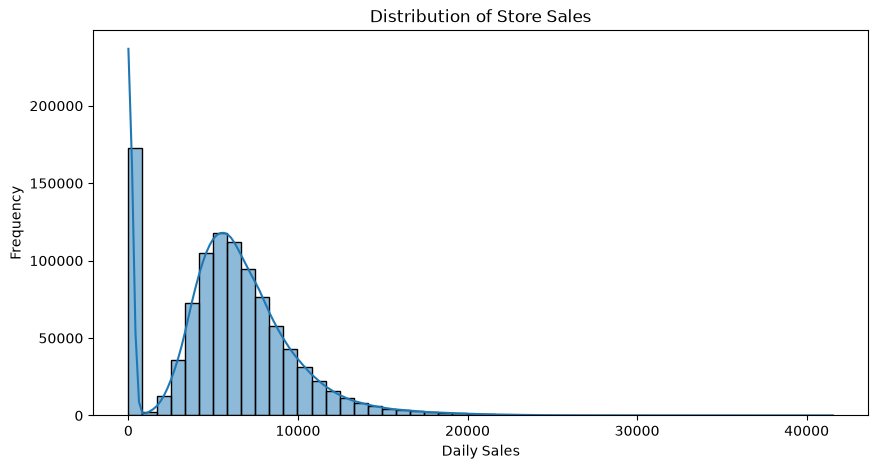

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df["Sales"], bins=50, kde=True)

plt.title("Distribution of Store Sales")
plt.xlabel("Daily Sales")
plt.ylabel("Frequency")

plt.show()

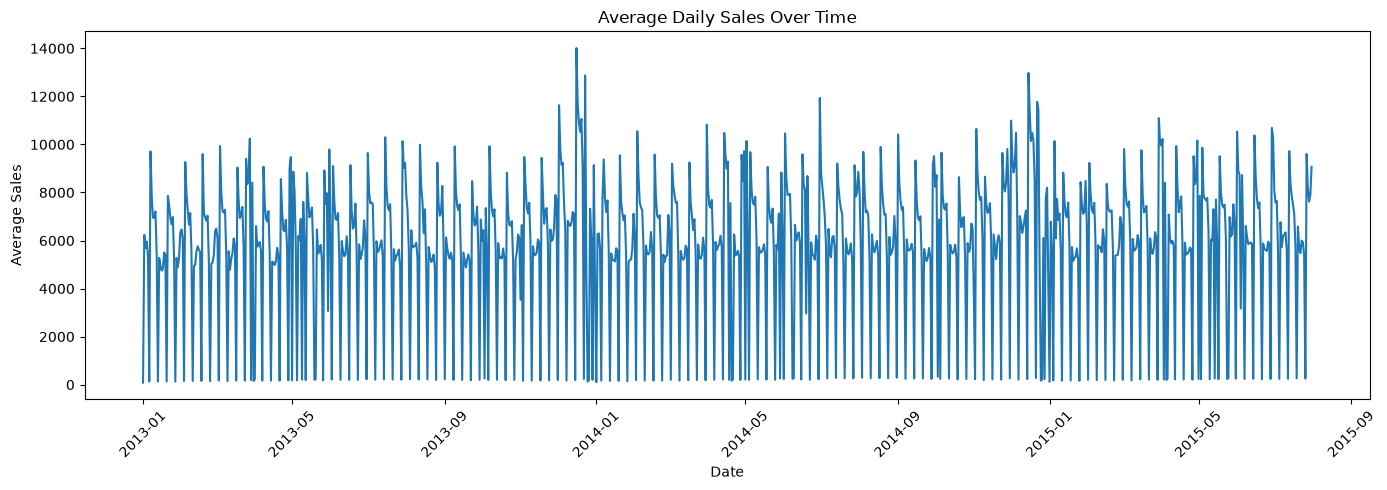

In [ ]:
# Average sales per day across all stores
daily_sales = df.groupby("Date")["Sales"].mean()

plt.figure(figsize=(14, 5))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Average Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64


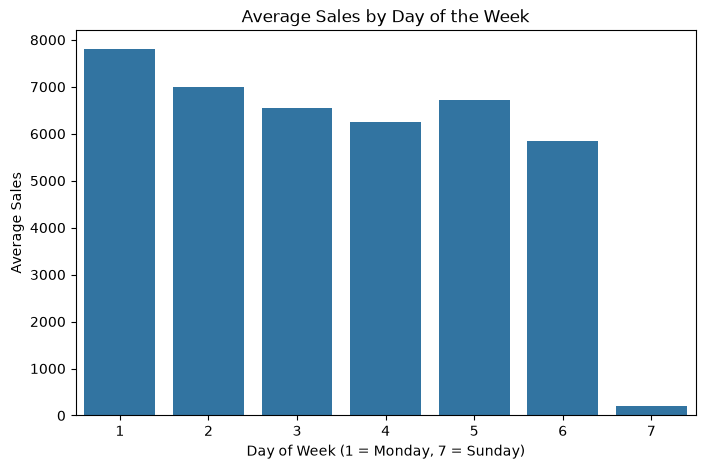

In [11]:

# Average sales by day of the week
sales_by_day = train.groupby("DayOfWeek")["Sales"].mean()

print(sales_by_day)

plt.figure(figsize=(8, 5))
sns.barplot(x=sales_by_day.index, y=sales_by_day.values)

plt.title("Average Sales by Day of the Week")
plt.xlabel("Day of Week (1 = Monday, 7 = Sunday)")
plt.ylabel("Average Sales")

plt.show()


Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


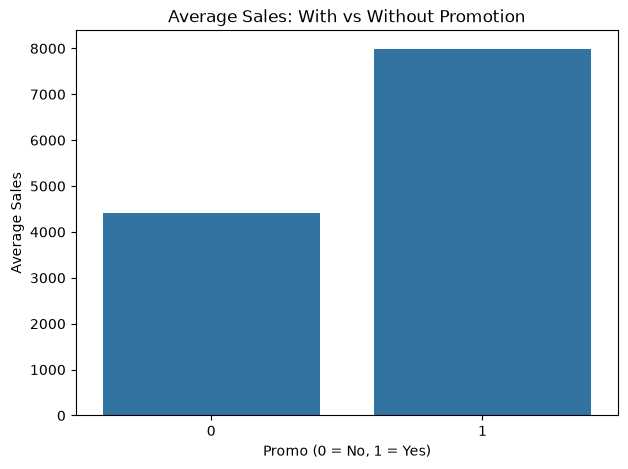

In [13]:

# Compare sales with and without promotions
promo_sales = train.groupby("Promo")["Sales"].mean()

print(promo_sales)

plt.figure(figsize=(7, 5))
sns.barplot(x=promo_sales.index, y=promo_sales.values)

plt.title("Average Sales: With vs Without Promotion")
plt.xlabel("Promo (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")

plt.show()


In [15]:
# Count open and closed store records
print(train["Open"].value_counts(dropna=False))

# Compare average sales for open and closed records
print(train.groupby("Open")["Sales"].mean())

Open
1    844392
0    172817
Name: count, dtype: int64
Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64


StateHoliday
0    5733.530624
0    5980.279717
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64


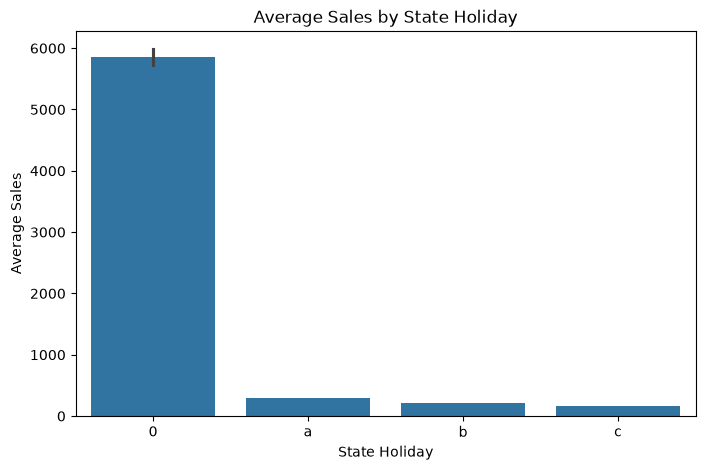

In [16]:
# Average sales by state holiday category
holiday_sales = train.groupby("StateHoliday")["Sales"].mean()

print(holiday_sales)

plt.figure(figsize=(8, 5))
sns.barplot(x=holiday_sales.index, y=holiday_sales.values)

plt.title("Average Sales by State Holiday")
plt.xlabel("State Holiday")
plt.ylabel("Average Sales")

plt.show()

SchoolHoliday
0    5620.979034
1    6476.522207
Name: Sales, dtype: float64


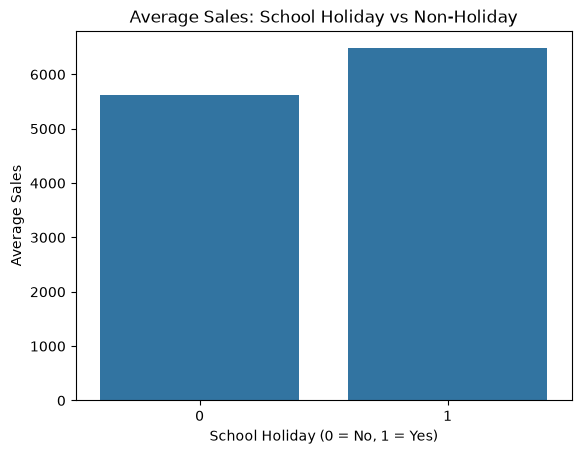

In [17]:
#Analyze school holidays
school_sales = train.groupby("SchoolHoliday")["Sales"].mean()

print(school_sales)

sns.barplot(x=school_sales.index, y=school_sales.values)
plt.title("Average Sales: School Holiday vs Non-Holiday")
plt.xlabel("School Holiday (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")
plt.show()

In [20]:

train = train.merge(store, on="Store", how="left")

print(train.columns)


Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')


StoreType
b    10058.837334
a     5738.179710
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64


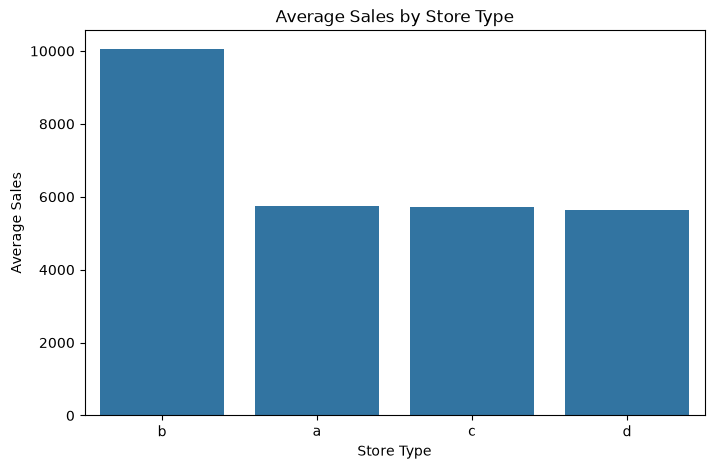

In [21]:

store_type_sales = train.groupby("StoreType")["Sales"].mean().sort_values(ascending=False)

print(store_type_sales)

plt.figure(figsize=(8, 5))
sns.barplot(x=store_type_sales.index, y=store_type_sales.values)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()


Assortment
b    8553.931999
c    6058.676567
a    5481.026096
Name: Sales, dtype: float64


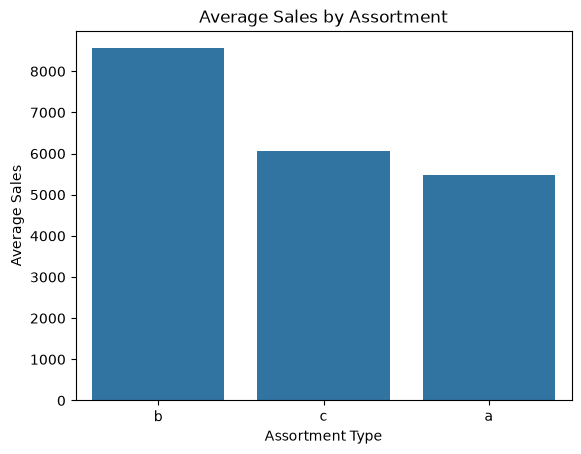

In [22]:
assortment_sales = train.groupby("Assortment")["Sales"].mean().sort_values(ascending=False)

print(assortment_sales)

sns.barplot(x=assortment_sales.index, y=assortment_sales.values)
plt.title("Average Sales by Assortment")
plt.xlabel("Assortment Type")
plt.ylabel("Average Sales")
plt.show()

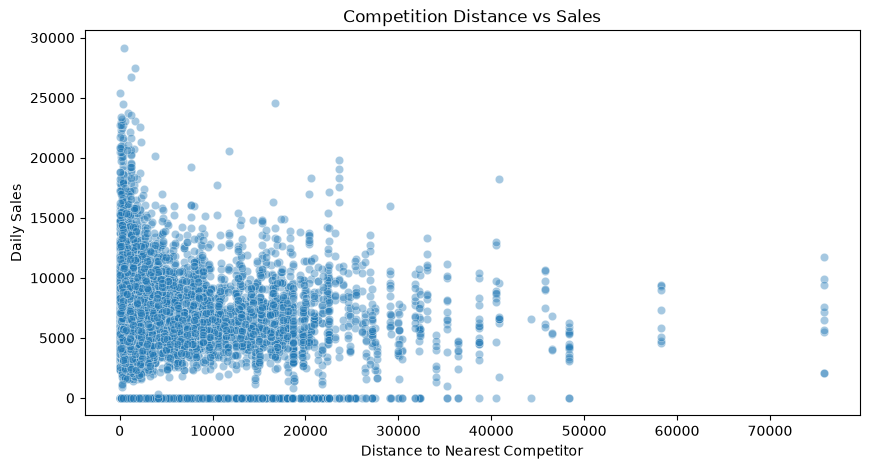

In [23]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=train.sample(10000, random_state=42),
    x="CompetitionDistance",
    y="Sales",
    alpha=0.4
)

plt.title("Competition Distance vs Sales")
plt.xlabel("Distance to Nearest Competitor")
plt.ylabel("Daily Sales")
plt.show()

In [25]:
print("Missing values in merged dataset:")
print(train.isnull().sum().sort_values(ascending=False).head(10))

Missing values in merged dataset:
PromoInterval                508031
Promo2SinceYear              508031
Promo2SinceWeek              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Promo2                            0
Assortment                        0
Store                             0
dtype: int64


In [27]:
print("Store status:")
print(train["Open"].value_counts(dropna=False))

print("\nClosed-store records:")
print((train["Open"] == 0).sum())

print("\nOpen stores with zero sales:")
print(((train["Open"] == 1) & (train["Sales"] == 0)).sum())

Store status:
Open
1    844392
0    172817
Name: count, dtype: int64

Closed-store records:
172817

Open stores with zero sales:
54


In [29]:

# Keep only open stores with positive sales
model_df = train[
    (train["Open"] == 1) &
    (train["Sales"] > 0)
].copy()

print("Original dataset:", train.shape)
print("Modeling dataset:", model_df.shape)


Original dataset: (1017209, 18)
Modeling dataset: (844338, 18)


In [30]:
model_df.to_csv("../data/rossmann_cleaned.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!


In [32]:
import pandas as pd

# Load datasets
train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")
test = pd.read_csv("../data/test.csv")

# Convert dates
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

# Merge training and store datasets
df = train.merge(store, on="Store", how="left")

# Sort by date
df = df.sort_values("Date").reset_index(drop=True)

# Create chronological splits
train_data = df[df["Date"] < "2015-06-01"].copy()

validation_data = df[
    (df["Date"] >= "2015-06-01") &
    (df["Date"] < "2015-07-01")
].copy()

test_data = df[
    (df["Date"] >= "2015-07-01") &
    (df["Date"] <= "2015-07-31")
].copy()

# Display results
print("Merged dataset:", df.shape)
print("Training:", train_data.shape)
print("Validation:", validation_data.shape)
print("July test period:", test_data.shape)

print("\nDate ranges:")
print("Training:", train_data["Date"].min(), "to", train_data["Date"].max())
print("Validation:", validation_data["Date"].min(), "to", validation_data["Date"].max())
print("July test period:", test_data["Date"].min(), "to", test_data["Date"].max())

C:\Users\Panchal Tanya\AppData\Local\Temp\ipykernel_13468\983296124.py:4: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


Merged dataset: (1017209, 18)
Training: (949194, 18)
Validation: (33450, 18)
July test period: (34565, 18)

Date ranges:
Training: 2013-01-01 00:00:00 to 2015-05-31 00:00:00
Validation: 2015-06-01 00:00:00 to 2015-06-30 00:00:00
July test period: 2015-07-01 00:00:00 to 2015-07-31 00:00:00


## Data Quality Observations

1. The training dataset contains historical sales records from January 2013 to July 2015.
2. The original training dataset has no missing values.
3. The store dataset contains missing values in CompetitionDistance and competition opening-date information.
4. Promo2 scheduling fields are missing for some stores that do not participate in Promo2.
5. The competition test dataset has 11 missing values in the Open column.
6. Missing CompetitionDistance values should not automatically be replaced with zero.
7. Closed stores and zero-sales records require careful handling during analysis and model training.
8. The Date column was converted to datetime format for time-based analysis.
9. The merged dataset contains 1,017,209 rows and 18 columns.
10. A chronological split was created to evaluate forecasting on later dates without randomly shuffling the data.

## Key Findings from Exploratory Data Analysis

1. **Sales distribution:** The sales histogram helps identify the distribution of daily store sales.
2. **Weekly seasonality:** Average sales vary across days of the week.
3. **Promotions:** Comparing promoted and non-promoted records helps evaluate the association between promotions and sales.
4. **State holidays:** Sales patterns can differ across state holiday categories.
5. **School holidays:** Comparing school-holiday and non-school-holiday records helps identify possible differences in sales.
6. **Store type:** Average sales can vary between store types.
7. **Assortment:** Product assortment categories may be associated with different sales levels.
8. **Competition distance:** The scatter plot helps investigate the relationship between competitor distance and sales.
9. **Store operating status:** Closed stores can affect average-sales comparisons and need careful treatment.
10. **Forecasting validation:** A chronological split is appropriate for evaluating predictions on future dates.

Note: These are analysis summaries. Use the actual printed results from your notebook to state which day or category has the highest sales.